In [ ]:
import pandas as pd

df = pd.read_csv("/content/vehicle_fraud.csv")

**Learn Data Analytics at [Slidescope](https://slidescope.com)**




In [ ]:
import seaborn as sns

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
df.head()

,Month,WeekOfMonth,DayOfWeek,Make,AccidentArea,DayOfWeekClaimed,MonthClaimed,WeekOfMonthClaimed,Sex,MaritalStatus,...,AgeOfVehicle,AgeOfPolicyHolder,PoliceReportFiled,WitnessPresent,AgentType,NumberOfSuppliments,AddressChange_Claim,NumberOfCars,Year,BasePolicy
0,Dec,5,Wednesday,Honda,Urban,Tuesday,Jan,1,Female,Single,...,3 years,26 to 30,No,No,External,none,1 year,3 to 4,1994,Liability
1,Jan,3,Wednesday,Honda,Urban,Monday,Jan,4,Male,Single,...,6 years,31 to 35,Yes,No,External,none,no change,1 vehicle,1994,Collision
2,Oct,5,Friday,Honda,Urban,Thursday,Nov,2,Male,Married,...,7 years,41 to 50,No,No,External,none,no change,1 vehicle,1994,Collision
3,Jun,2,Saturday,Toyota,Rural,Friday,Jul,1,Male,Married,...,more than 7,51 to 65,Yes,No,External,more than 5,no change,1 vehicle,1994,Liability
4,Jan,5,Monday,Honda,Urban,Tuesday,Feb,2,Female,Single,...,5 years,31 to 35,No,No,External,none,no change,1 vehicle,1994,Collision


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15420 entries, 0 to 15419
Data columns (total 33 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Month                 15420 non-null  object
 1   WeekOfMonth           15420 non-null  int64 
 2   DayOfWeek             15420 non-null  object
 3   Make                  15420 non-null  object
 4   AccidentArea          15420 non-null  object
 5   DayOfWeekClaimed      15420 non-null  object
 6   MonthClaimed          15420 non-null  object
 7   WeekOfMonthClaimed    15420 non-null  int64 
 8   Sex                   15420 non-null  object
 9   MaritalStatus         15420 non-null  object
 10  Age                   15420 non-null  int64 
 11  Fault                 15420 non-null  object
 12  PolicyType            15420 non-null  object
 13  VehicleCategory       15420 non-null  object
 14  VehiclePrice          15420 non-null  object
 15  FraudFound_P          15420 non-null

In [ ]:
#Num of Claims
numclaims = df['PolicyNumber'].nunique()
numclaims


15420

In [ ]:
# Fraudulent Claims
fraudclaims = df[df['FraudFound_P'] == 1]['PolicyNumber'].nunique()
fraudclaims


923

In [ ]:
# Fraud Rate
fraudrate = (fraudclaims/numclaims)*100
fraudrate

5.985732814526589

In [ ]:
# add three kpis numclaims, fraudclaims, fraudrate in one table as 3 columns
df1 = pd.DataFrame({'numclaims': [numclaims], 'fraudclaims': [fraudclaims], 'fraudrate': [fraudrate]})
df1

,numclaims,fraudclaims,fraudrate
0,15420,923,5.985733


In [ ]:
# fraudulent claims by sex
fraudclaimsbysex = df[df['FraudFound_P'] == 1].groupby('Sex').size()
fraudclaimsbysex

,0
Sex,
Female,105
Male,818


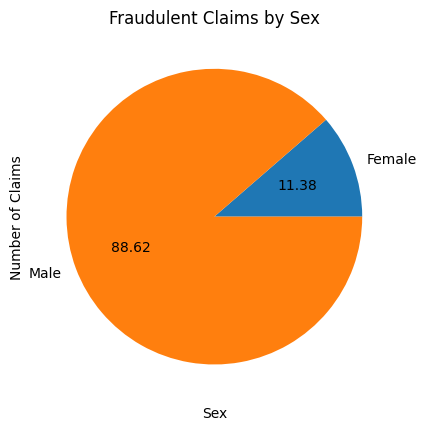

In [ ]:
fraudclaimsbysex.plot(kind='pie', autopct='%.2f')
plt.title('Fraudulent Claims by Sex')
plt.xlabel('Sex')
plt.ylabel('Number of Claims')
plt.show()

In [ ]:
# Fraudulent Claims by Marital Status
fraudclaimsbymarital = df[df['FraudFound_P'] == 1].groupby('MaritalStatus').size()
fraudclaimsbymarital

,0
MaritalStatus,
Divorced,3
Married,639
Single,278
Widow,3


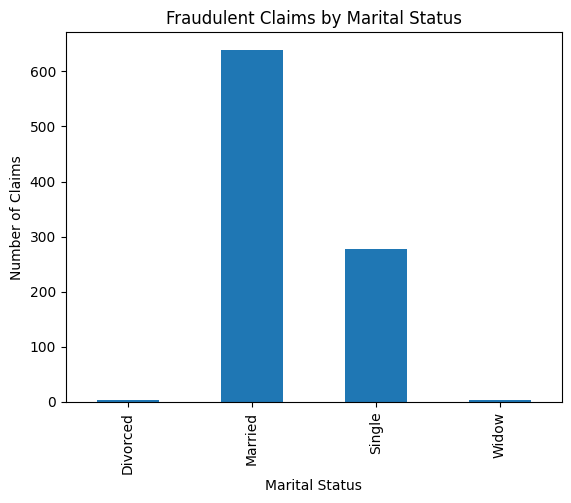

In [ ]:
# show fraudclaimsbymarital in a bar chart
fraudclaimsbymarital.plot(kind='bar')
plt.title('Fraudulent Claims by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Number of Claims')
plt.show()

In [ ]:
# Fraudulent Claims by Age of Policy Holder in bar horizontal
fraudclaimsbyage = df[df['FraudFound_P'] == 1].groupby('AgeOfPolicyHolder').size()
fraudclaimsbyage

,0
AgeOfPolicyHolder,
16 to 17,31
18 to 20,2
21 to 25,16
26 to 30,33
31 to 35,360
36 to 40,237
41 to 50,144
51 to 65,70
over 65,30


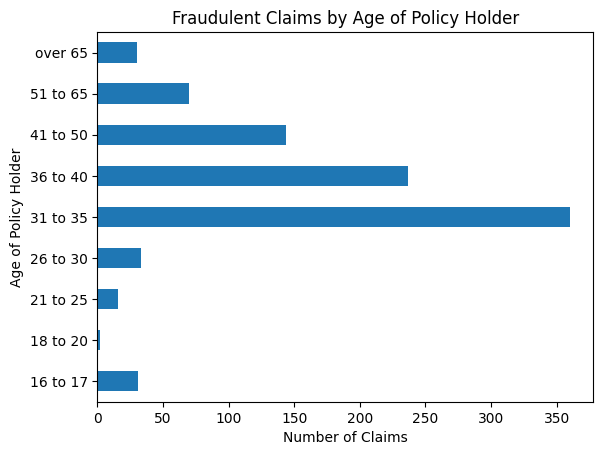

In [ ]:
# fraudclaimsbyage in bar horizontal
fraudclaimsbyage.plot(kind='barh')
plt.title('Fraudulent Claims by Age of Policy Holder')
plt.xlabel('Number of Claims')
plt.ylabel('Age of Policy Holder')
plt.show()

In [ ]:
# Top 5 Make by category and by Fraud Claims Count
top5make = df[df['FraudFound_P'] == 1].groupby('Make').size().sort_values(ascending=False).head(5)
top5make


,0
Make,
Pontiac,213
Toyota,186
Honda,179
Mazda,123
Chevrolet,94


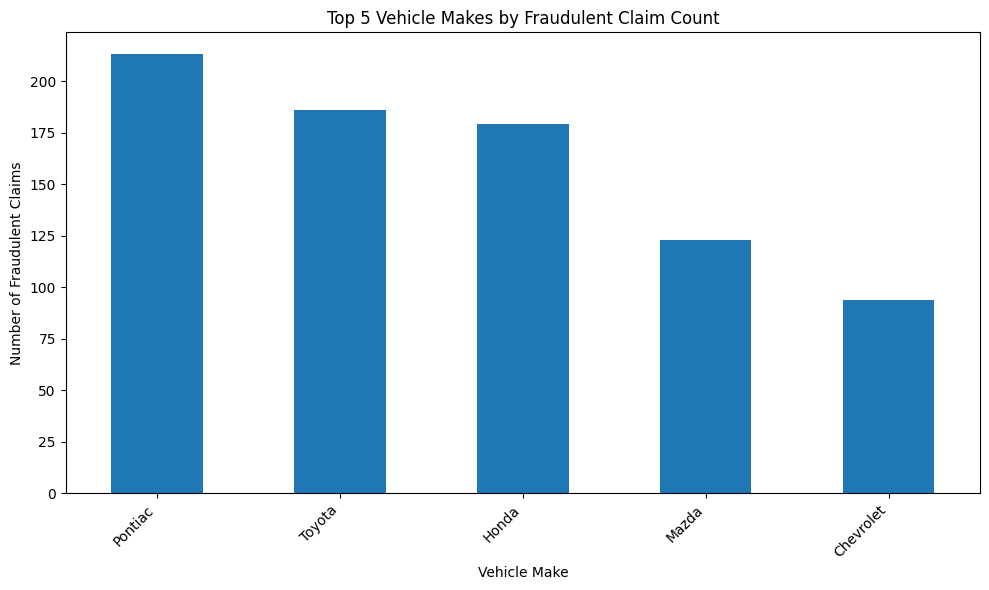

In [ ]:
# Group by Make and VehicleCategory, summing up the FraudFound_P
grouped_df = df.groupby(['Make', 'VehicleCategory'])['FraudFound_P'].sum().unstack(fill_value=0)


In [ ]:
grouped_df

VehicleCategory,Sedan,Sport,Utility
Make,,,
Accura,37,3,19
BMW,1,0,0
Chevrolet,77,5,12
Dodge,2,0,0
Ferrari,0,0,0
Ford,27,2,4
Honda,133,44,2
Jaguar,0,0,0
Lexus,0,0,0


In [ ]:
# Optional: Sort by total fraud cases across all categories
grouped_df = grouped_df.loc[grouped_df.sum(axis=1).sort_values(ascending=False).index]


In [ ]:
grouped_df

VehicleCategory,Sedan,Sport,Utility
Make,,,
Pontiac,202,5,6
Toyota,171,15,0
Honda,133,44,2
Mazda,114,9,0
Chevrolet,77,5,12
Accura,37,3,19
Ford,27,2,4
Saab,11,0,0
VW,8,0,0


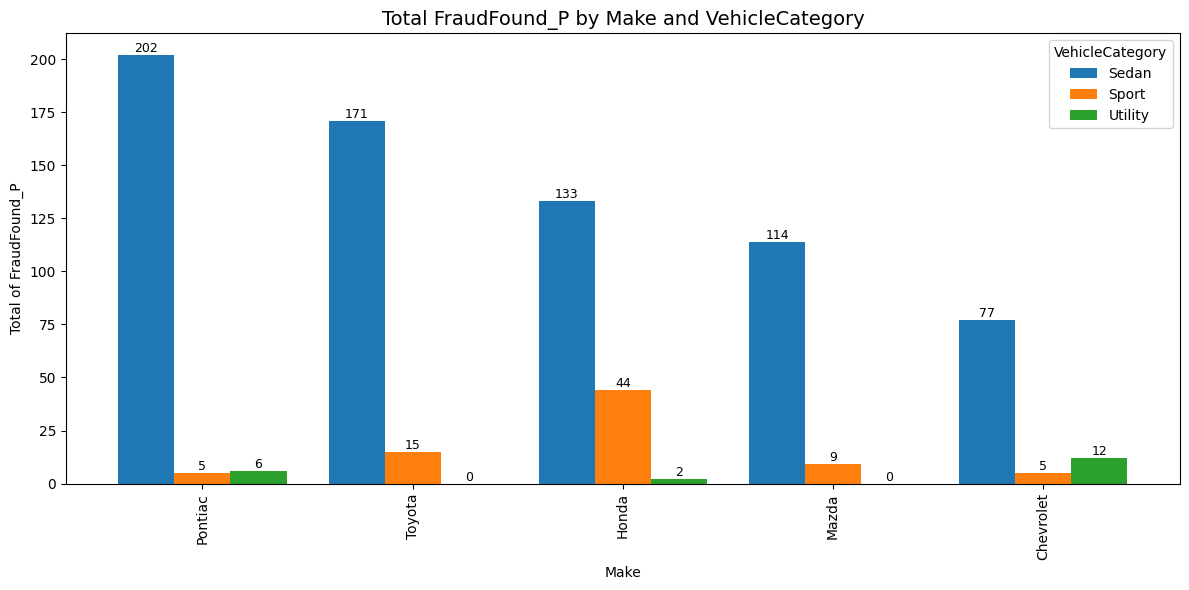

In [ ]:
# Plot the grouped bar chart
ax = grouped_df.head(5).plot(kind='bar', figsize=(12, 6), width=0.8)

# Title and labels
plt.title('Total FraudFound_P by Make and VehicleCategory', fontsize=14)
plt.ylabel('Total of FraudFound_P')
plt.xlabel('Make')

# Add value labels on each bar
for container in ax.containers:
    ax.bar_label(container, label_type='edge', fontsize=9)

# Legend with title
plt.legend(title='VehicleCategory')

# Clean layout
plt.tight_layout()

# Show the plot
plt.show()